In [1]:
import torch
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score 

from nnfabrik.builder import get_data, get_trainer

from model import stacked_core_full_gauss_readout
from autoencoder import VAE

from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

random_seed = 42

device = "cuda:7"
torch.cuda.set_device(device)

In [3]:
def cluster(points, n_cluster, seed):
    kmeans = KMeans(n_clusters=n_cluster, random_state=seed)
    labels = kmeans.fit_predict(points)
    
    return labels

def multi_cluster(points, n_cluster, n_runs=10):
    labels = np.array([cluster(points, n_cluster, seed) for seed in range(n_runs)])
    
    aris = []
    for i in range(n_runs):
        for j in range(i):
            aris.append(adjusted_rand_score(labels[i], labels[j]))

    return np.array(aris).mean()

In [4]:
checkpoint = torch.load('model_weights.pth')
features = checkpoint['readout.23343-5-17._features']
features = features.squeeze().permute(1, 0).detach().cpu().numpy()

averaging 45 comparisons


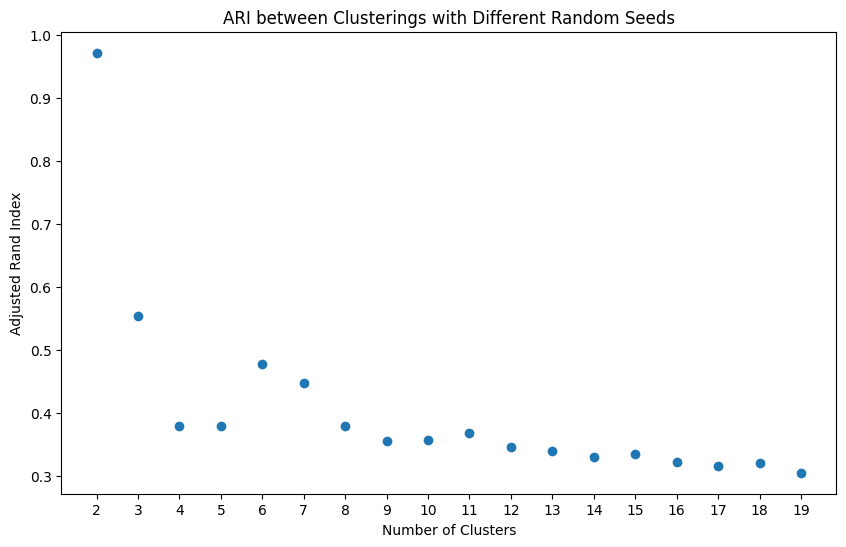

In [5]:
ari_results = []

n_cluster_range = range(2, 20)
n_runs = 10
print(f'averaging {int(n_runs * (n_runs - 1) / 2)} comparisons')
for n_cluster in n_cluster_range:
    ari = multi_cluster(features, n_cluster)
    ari_results.append(ari)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(n_cluster_range, ari_results)
plt.xlabel('Number of Clusters')
plt.ylabel('Adjusted Rand Index')
plt.title('ARI between Clusterings with Different Random Seeds')
plt.xticks(n_cluster_range)
plt.show()


In [6]:
# loading the SENSORIUM+ dataset
filenames = [
    "/srv/user/polina/sensorium/sensorium/notebooks/data/static23343-5-17-GrayImageNet-94c6ff995dac583098847cfecd43e7b6.zip",
    #"/srv/user/polina/sensorium/sensorium/notebooks/data/static21067-10-18-GrayImageNet-94c6ff995dac583098847cfecd43e7b6.zip", 

]
data_key = '23343-5-17'

dataset_fn = "sensorium.datasets.static_loaders"
dataset_config = {
    "paths": filenames,
    "normalize": True,
    "exclude": None,
    "include_behavior": False,
    "include_eye_position": False,
    "batch_size": 128,
    "scale": 0.25,
}

dataloaders = get_data(dataset_fn, dataset_config)

In [7]:
model_config = {
    "pad_input": False,
    "stack": -1,
    "layers": 4,
    "input_kern": 9,
    "gamma_input": 6.3831,
    "gamma_readout": 0.0076,
    "hidden_kern": 7,
    "hidden_channels": 64,
    "depth_separable": True,
    "grid_mean_predictor": {
        "type": "cortex",
        "input_dimensions": 2,
        "hidden_layers": 1,
        "hidden_features": 30,
        "final_tanh": True,
    },
    "init_sigma": 0.1,
    "init_mu_range": 0.3,
    "gauss_type": "full",
    "shifter": False, 
    "autoencoder": None, 
}

autoencoder = VAE(64, 16, [1024], batch_norm=False, dropout=0., nonlinearity='GELU')
model_config['autoencoder'] = autoencoder
model = stacked_core_full_gauss_readout(dataloaders, 42, **model_config)

/srv/user/nathanpaul.soeding/private_neuropredictors/neuralpredictors/layers/readouts/base.py:74: UserWarning: Use of 'gamma_readout' is deprecated. Use 'feature_reg_weight' instead. If 'feature_reg_weight' is defined, 'gamma_readout' is ignored
  warnings.warn(
/srv/user/nathanpaul.soeding/private_neuropredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")


In [8]:
model.load_state_dict(torch.load('model_autoenc_weights.pth'))

<All keys matched successfully>

In [9]:
features = model.readout[data_key]._features.squeeze().permute(1, 0)

mu, logvar = model.readout[data_key].autoencoder.encode(features)
mu = mu.detach().cpu().numpy()

averaging 45 comparisons


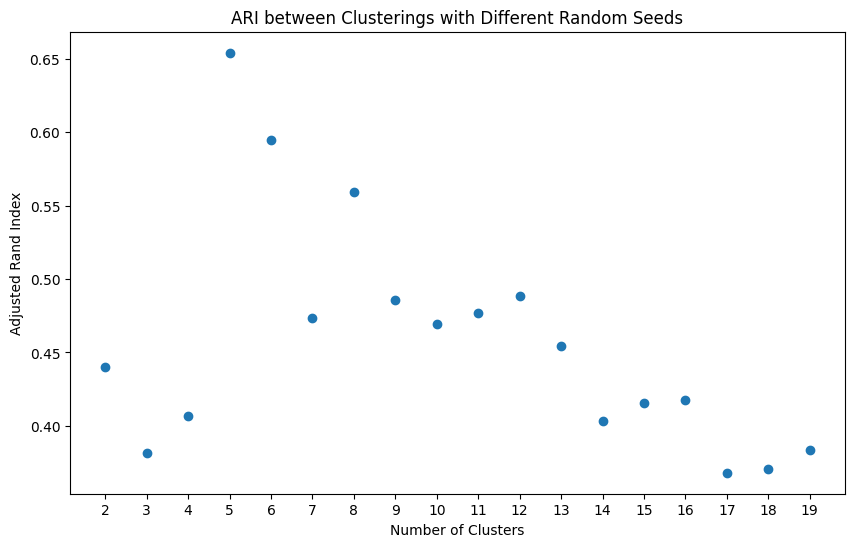

In [10]:
ari_results = []

n_cluster_range = range(2, 20)
n_runs = 10
print(f'averaging {int(n_runs * (n_runs - 1) / 2)} comparisons')
for n_cluster in n_cluster_range:
    ari = multi_cluster(mu, n_cluster)
    ari_results.append(ari)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(n_cluster_range, ari_results)
plt.xlabel('Number of Clusters')
plt.ylabel('Adjusted Rand Index')
plt.title('ARI between Clusterings with Different Random Seeds')
plt.xticks(n_cluster_range)
plt.show()
